In [1]:
! pip install librosa

import kagglehub
import os
import shutil
import os
import json
import random
import torch
import librosa
import numpy as np
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch import nn
from torch.nn import LSTM, Linear, Conv2d, MaxPool2d, Dropout
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

In [2]:
import os
import json
import random
import numpy as np
import torch
import torch.nn.functional as F
import librosa
from torch.utils.data import Dataset

class GuitarSetPatchDataset(Dataset):
    def __init__(self, audio_dir, jams_dir, sample_rate=22050, hop_length=512, patch_seconds=10.0, is_train=False):
        self.audio_dir = audio_dir
        self.jams_dir = jams_dir
        self.sample_rate = sample_rate
        self.hop_length = hop_length
        self.is_train = is_train

        self.patch_frames = int(np.floor((patch_seconds * sample_rate) / hop_length))

        self.classes = [
            "C:maj", "C#:maj", "D:maj", "D#:maj", "E:maj", "F:maj",
            "F#:maj", "G:maj", "G#:maj", "A:maj", "A#:maj", "B:maj",
            "C:min", "C#:min", "D:min", "D#:min", "E:min", "F:min",
            "F#:min", "G:min", "G#:min", "A:min", "A#:min", "B:min", "N"
        ]
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

        self.files = []
        for file in os.listdir(jams_dir):
            if file.endswith(".jams"):
                base_name = file.replace(".jams", "")
                wav_path = os.path.join(audio_dir, f"{base_name}_mic.wav")
                jams_path = os.path.join(jams_dir, file)

                if os.path.exists(wav_path):
                    self.files.append((wav_path, jams_path))

    def _simplify_chord(self, chord_string):
        if chord_string in ["N", "Z", "sil"]: return "N"
        root_triad = chord_string.split('/')[0]
        parts = root_triad.split(':')
        root = parts[0]
        quality = "maj" if len(parts) == 1 else ("min" if parts[1].startswith('min') else "maj")
        simplified = f"{root}:{quality}"
        return simplified if simplified in self.class_to_idx else "N"

    def _get_frame_labels(self, jams_path, num_frames):
        labels = np.full(num_frames, self.class_to_idx["N"], dtype=np.int64)
        with open(jams_path, 'r') as f:
            jams_data = json.load(f)

        chord_annotations = next((ann['data'] for ann in jams_data['annotations'] if ann['namespace'] == 'chord'), None)
        if not chord_annotations: return torch.tensor(labels, dtype=torch.long)

        for obs in chord_annotations:
            start_frame = int(np.floor((obs['time'] * self.sample_rate) / self.hop_length))
            end_frame = int(np.floor(((obs['time'] + obs['duration']) * self.sample_rate) / self.hop_length))
            end_frame = min(end_frame, num_frames)

            if start_frame < num_frames:
                labels[start_frame:end_frame] = self.class_to_idx[self._simplify_chord(obs['value'])]
        return torch.tensor(labels, dtype=torch.long)

    def _shift_labels(self, targets, shift):
        """Mathematically transposes chord labels by N semitones"""
        shifted_targets = targets.clone()
        mask = targets != 24 # Ignore 'N' (Silence)

        roots = targets[mask] % 12
        qualities = (targets[mask] >= 12).long() * 12

        new_roots = (roots + shift) % 12
        shifted_targets[mask] = new_roots + qualities

        return shifted_targets

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        wav_path, jams_path = self.files[idx]

        y, sr = librosa.load(wav_path, sr=self.sample_rate, mono=True)
        cqt = np.abs(librosa.cqt(y=y, sr=self.sample_rate, hop_length=self.hop_length, n_bins=84, bins_per_octave=12))
        cqt_db = librosa.amplitude_to_db(cqt, ref=np.max)

        shift = 0
        if self.is_train and random.random() < 0.5:
            shift = random.randint(-1, 1)

        if shift > 0:
            cqt_db[shift:, :] = cqt_db[:-shift, :]
            cqt_db[:shift, :] = -80.0
        elif shift < 0:
            cqt_db[:shift, :] = cqt_db[-shift:, :]
            cqt_db[shift:, :] = -80.0

        full_features = torch.tensor(cqt_db, dtype=torch.float32)
        num_frames = full_features.shape[1]
        full_targets = self._get_frame_labels(jams_path, num_frames)

        if shift != 0:
            full_targets = self._shift_labels(full_targets, shift)

        if num_frames > self.patch_frames:
            start_idx = random.randint(0, num_frames - self.patch_frames)
            end_idx = start_idx + self.patch_frames
            features = full_features[:, start_idx:end_idx]
            targets = full_targets[start_idx:end_idx]
        elif num_frames < self.patch_frames:
            pad_amount = self.patch_frames - num_frames
            features = F.pad(full_features, (0, pad_amount), value=-80.0)
            targets = F.pad(full_targets, (0, pad_amount), value=self.class_to_idx["N"])
        else:
            features = full_features
            targets = full_targets

        features = features.unsqueeze(0)
        return features, targets

In [3]:
from torch.utils.data import DataLoader
import random

jams_dir = "./files/annotation"
audio_dir = "./files/audio_mono-mic"
all_files = [f for f in os.listdir(jams_dir) if f.endswith(".jams")]

all_files.sort()
random.seed(42)
random.shuffle(all_files)

train_size = int(len(all_files) * 0.8)
train_files = all_files[:train_size]
test_files = all_files[train_size:]

train_dataset = GuitarSetPatchDataset(audio_dir, jams_dir, patch_seconds=10.0, is_train=True)
train_dataset.files = [(os.path.join(audio_dir, f.replace(".jams", "_mic.wav")), os.path.join(jams_dir, f)) for f in train_files]

test_dataset = GuitarSetPatchDataset(audio_dir, jams_dir, patch_seconds=10.0, is_train=False)
test_dataset.files = [(os.path.join(audio_dir, f.replace(".jams", "_mic.wav")), os.path.join(jams_dir, f)) for f in test_files]

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Dataset securely split and augmented: Training on {len(train_dataset)} files, Testing on {len(test_dataset)} files.")

Dataset securely split and augmented: Training on 288 files, Testing on 72 files.


In [4]:
import math
import torch
import torch.nn as nn

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=1000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: (Time, Batch, Features)
        x = x + self.pe[:x.size(0)]
        return self.dropout(x)

class ChordTransformer(nn.Module):
    def __init__(self, num_classes=25, d_model=256, nhead=8, num_layers=4):
        super(ChordTransformer, self).__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 1)),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 1)),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 1)),
            nn.Dropout2d(0.3)
        )
        self.cnn_output_size = 128 * 10

        self.feature_projection = nn.Sequential(
            nn.Linear(self.cnn_output_size, d_model),
            nn.ReLU(),
            nn.Dropout(0.1)
        )

        self.pos_encoder = PositionalEncoding(d_model, dropout=0.1)
        encoder_layers = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=0.1,
            batch_first=False,
            norm_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # x input shape: (Batch, 1, 84, Time)
        features = self.cnn(x)
        Batch, Channels, Freqs, Time = features.size()
        features = features.permute(0, 3, 1, 2).contiguous()
        features = features.view(Batch, Time, -1)
        features = self.feature_projection(features)
        features = features.permute(1, 0, 2)
        features = self.pos_encoder(features)
        transformer_out = self.transformer_encoder(features)
        transformer_out = transformer_out.permute(1, 0, 2)
        logits = self.classifier(transformer_out)
        return logits

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ChordTransformer(num_classes=25).to(device)

/home/Davidencu/Bitdefender-AC-Labs/venv_tf/lib64/python3.13/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [ ]:
from torch import optim

def apply_spec_augment(x, num_freq_masks=2, num_time_masks=2, freq_mask_param=8, time_mask_param=20):
    cloned = x.clone()
    batch, _, num_freq, num_time = cloned.shape

    for _ in range(num_freq_masks):
        f = torch.randint(0, freq_mask_param, (batch,))
        f0 = torch.randint(0, num_freq - freq_mask_param, (batch,))
        for i in range(batch):
            cloned[i, 0, f0[i]:f0[i]+f[i], :] = -80

    for _ in range(num_time_masks):
        t = torch.randint(0, time_mask_param, (batch,))
        t0 = torch.randint(0, num_time - time_mask_param, (batch,))
        for i in range(batch):
            cloned[i, 0, :, t0[i]:t0[i]+t[i]] = -80

    return cloned

def train_one_epoch(model, train_dataloader, test_dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    train_correct = 0
    train_total = 0

    for features, targets in train_dataloader:
        features, targets = features.to(device), targets.to(device)
        optimizer.zero_grad()
        augmented_features = apply_spec_augment(features)
        outputs = model(augmented_features) # Shape: (Batch, Time, 25) - Class probabilities for each time frame

        loss = criterion(outputs.view(-1, outputs.shape[-1]), targets.view(-1))
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

        predictions = torch.argmax(outputs, dim=-1)
        train_correct += (predictions == targets).sum().item()
        train_total += targets.numel()

    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for features, targets in test_dataloader:
            features, targets = features.to(device), targets.to(device)
            outputs = model(features)

            loss = criterion(outputs.view(-1, outputs.shape[-1]), targets.view(-1))
            test_loss += loss.item()

            predictions = torch.argmax(outputs, dim=-1)
            test_correct += (predictions == targets).sum().item()
            test_total += targets.numel()

    train_acc = train_correct / train_total
    test_acc = test_correct / test_total

    return total_loss / len(train_dataloader), train_acc, test_loss / len(test_dataloader), test_acc


def train_model(model, train_dataloader, test_dataloader, criterion, optimizer, num_epochs, device):
    train_losses, test_losses = [], []
    train_accs, test_accs = [], []

    best_test_loss = float('inf')
    for epoch in range(num_epochs):
        train_loss, train_acc, test_loss, test_acc = train_one_epoch(model, train_dataloader, test_dataloader, criterion, optimizer, device)

        print(f"Epoch {epoch + 1}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f}, Acc: {train_acc*100:.2f}% | "
              f"Test Loss: {test_loss:.4f}, Acc: {test_acc*100:.2f}%")

        if test_loss < best_test_loss:
            # Update the high score
            best_test_loss = test_loss

            torch.save(model.state_dict(), './files/best_transformer_model.pth')
            print(f"Checkpoint Saved! New best test loss: {best_test_loss:.4f}")

        train_losses.append(train_loss)
        test_losses.append(test_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)

    print("Training Complete!")
    return train_losses, test_losses, train_accs, test_accs

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ChordTransformer(num_classes=25).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

print("Scanning training set to calculate smoothed class penalty weights...")
class_counts = torch.zeros(25)

for _, targets in train_dataloader:
    for class_idx in range(25):
        class_counts[class_idx] += (targets == class_idx).sum().item()

class_counts = torch.where(class_counts == 0, torch.tensor(1.0), class_counts)
weights = 1.0 / torch.sqrt(class_counts)
weights = weights / weights.sum() * 25.0

print("\nSmoothed Class Weights Calculated. Initializing Criterion...")
criterion = nn.CrossEntropyLoss(weight=weights.to(device))

total_epochs = 200
steps_per_epoch = len(train_dataloader)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=3e-4,
    epochs=total_epochs,
    steps_per_epoch=steps_per_epoch,
    pct_start=0.1,
    anneal_strategy='cos'
)

train_model(model,train_dataloader,test_dataloader,criterion,optimizer,total_epochs,device)

/home/Davidencu/Bitdefender-AC-Labs/venv_tf/lib64/python3.13/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Scanning training set to calculate smoothed class penalty weights...

Smoothed Class Weights Calculated. Initializing Criterion...
Epoch 1/200 | Train Loss: 3.2869, Acc: 4.50% | Test Loss: 3.2144, Acc: 5.91%
Checkpoint Saved! New best test loss: 3.2144
Epoch 2/200 | Train Loss: 3.2277, Acc: 5.60% | Test Loss: 3.1685, Acc: 8.66%
Checkpoint Saved! New best test loss: 3.1685
Epoch 3/200 | Train Loss: 3.1965, Acc: 6.91% | Test Loss: 3.1548, Acc: 7.93%
Checkpoint Saved! New best test loss: 3.1548
Epoch 4/200 | Train Loss: 3.1874, Acc: 6.73% | Test Loss: 3.1577, Acc: 6.36%
Epoch 5/200 | Train Loss: 3.1859, Acc: 6.33% | Test Loss: 3.1348, Acc: 8.34%
Checkpoint Saved! New best test loss: 3.1348
Epoch 6/200 | Train Loss: 3.1791, Acc: 6.64% | Test Loss: 3.1401, Acc: 7.45%
Epoch 7/200 | Train Loss: 3.1808, Acc: 6.79% | Test Loss: 3.1575, Acc: 5.24%
Epoch 8/200 | Train Loss: 3.1663, Acc: 7.01% | Test Loss: 3.1337, Acc: 7.83%
Checkpoint Saved! New best test loss: 3.1337
Epoch 9/200 | Train Loss: 3.

KeyboardInterrupt: 

Generating Confusion Matrix on isolated test data...


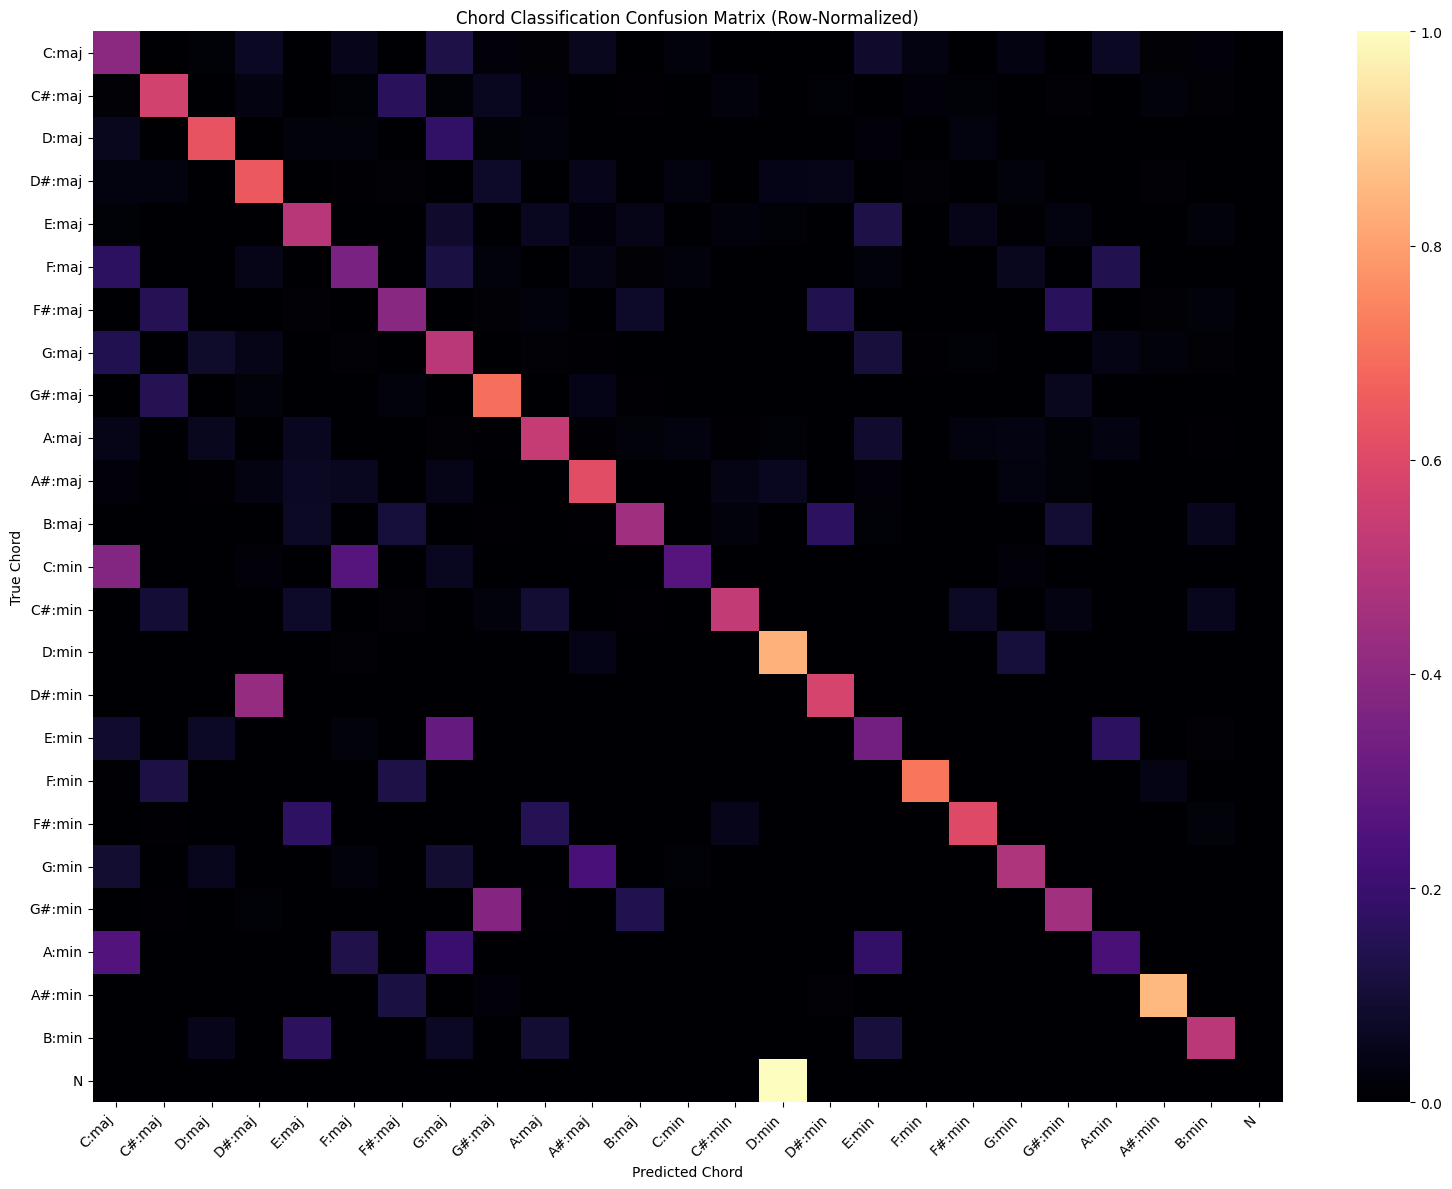

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import torch

def plot_confusion_matrix(model, test_dataloader, device, classes):
    print("Generating Confusion Matrix on isolated test data...")
    model.eval()

    all_preds = []
    all_targets = []

    model.load_state_dict(torch.load('./files/best_transformer_model.pth', map_location=device))

    with torch.no_grad():
        for features, targets in test_dataloader:
            features = features.to(device)
            targets = targets.view(-1).cpu().numpy()

            outputs = model(features)
            preds = torch.argmax(outputs, dim=-1).view(-1).cpu().numpy()

            all_preds.extend(preds)
            all_targets.extend(targets)

    cm = confusion_matrix(all_targets, all_preds, labels=range(len(classes)))

    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_normalized = np.nan_to_num(cm_normalized) # Handle division by zero if a class is entirely missing

    plt.figure(figsize=(16, 12))
    sns.heatmap(cm_normalized, annot=False, cmap="magma", xticklabels=classes, yticklabels=classes)
    plt.title("Chord Classification Confusion Matrix (Row-Normalized)")
    plt.ylabel("True Chord")
    plt.xlabel("Predicted Chord")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

CHORD_CLASSES = [
    "C:maj", "C#:maj", "D:maj", "D#:maj", "E:maj", "F:maj",
    "F#:maj", "G:maj", "G#:maj", "A:maj", "A#:maj", "B:maj",
    "C:min", "C#:min", "D:min", "D#:min", "E:min", "F:min",
    "F#:min", "G:min", "G#:min", "A:min", "A#:min", "B:min", "N"
]

plot_confusion_matrix(model, test_dataloader, device, CHORD_CLASSES)

In [11]:
from scipy.ndimage import median_filter

CHORD_CLASSES = [
    'C:maj', 'C#:maj', 'D:maj', 'D#:maj', 'E:maj', 'F:maj', 'F#:maj', 'G:maj', 'G#:maj', 'A:maj', 'A#:maj', 'B:maj',
    'C:min', 'C#:min', 'D:min', 'D#:min', 'E:min', 'F:min', 'F#:min', 'G:min', 'G#:min', 'A:min', 'A#:min', 'B:min',
    'N'
]

import torch
import numpy as np
import librosa
from scipy.ndimage import median_filter

def process_full_song_overlapping(audio_path, model, device, patch_seconds=10.0, overlap_seconds=5.0, sr=22050, hop_length=512):
    print(f"Loading {audio_path} with overlapping context...")

    y, _ = librosa.load(audio_path, sr=sr, mono=True)
    cqt = np.abs(librosa.cqt(y, sr=sr, hop_length=hop_length, fmin=librosa.note_to_hz('C2'), n_bins=84, bins_per_octave=12))
    cqt_db = librosa.amplitude_to_db(cqt, ref=np.max)

    total_frames = cqt_db.shape[1]
    frames_per_patch = int((patch_seconds * sr) / hop_length)
    step_frames = int(((patch_seconds - overlap_seconds) * sr) / hop_length)

    accumulated_logits = np.zeros((total_frames, 25), dtype=np.float32)
    overlap_counts = np.zeros(total_frames, dtype=np.float32)

    model.eval()

    print("Running overlapping inference...")
    with torch.no_grad():
        for start_frame in range(0, total_frames, step_frames):
            end_frame = start_frame + frames_per_patch

            chunk = cqt_db[:, start_frame:min(end_frame, total_frames)]
            actual_length = chunk.shape[1]

            if actual_length < frames_per_patch:
                pad_width = frames_per_patch - actual_length
                chunk = np.pad(chunk, ((0, 0), (0, pad_width)), mode='constant', constant_values=-80.0)

            tensor_chunk = torch.tensor(chunk, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

            logits = model(tensor_chunk).squeeze(0).cpu().numpy() # Shape: (frames_per_patch, 25)

            accumulated_logits[start_frame:start_frame + actual_length] += logits[:actual_length]
            overlap_counts[start_frame:start_frame + actual_length] += 1

    overlap_counts[overlap_counts == 0] = 1
    averaged_logits = accumulated_logits / overlap_counts[:, None]

    final_predictions = np.argmax(averaged_logits, axis=-1)

    return final_predictions, sr, hop_length

def compress_predictions(predictions, sr, hop_length):
    """
    Compresses frame-by-frame predictions into readable chord blocks (e.g., 0.00s - 2.50s: C:maj)
    """
    if len(predictions) == 0:
        return []

    compressed = []
    current_chord = predictions[0]
    start_frame = 0

    for i in range(1, len(predictions)):
        if predictions[i] != current_chord:
            start_time = (start_frame * hop_length) / sr
            end_time = (i * hop_length) / sr
            compressed.append((start_time, end_time, CHORD_CLASSES[current_chord]))

            current_chord = predictions[i]
            start_frame = i

    start_time = (start_frame * hop_length) / sr
    end_time = (len(predictions) * hop_length) / sr
    compressed.append((start_time, end_time, CHORD_CLASSES[current_chord]))

    return compressed

if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = ChordTransformer(num_classes=25).to(device)

    model.load_state_dict(torch.load('./files/best_transformer_model.pth', map_location=device))

    audio_file = "./files/let_her_go.wav"

    raw_preds, sr, hop = process_full_song_overlapping(audio_file, model, device, patch_seconds=10.0, overlap_seconds=5.0)

    smoothed_preds = median_filter(raw_preds, size=15)

    timeline = compress_predictions(smoothed_preds, sr, hop)

    print("\nCHORD TIMELINE\n")
    for start, end, chord in timeline:
        if (end - start) > 0.2:
            print(f"[{start:05.2f}s - {end:05.2f}s] : {chord}")

/home/Davidencu/Bitdefender-AC-Labs/venv_tf/lib64/python3.13/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Loading ./files/let_her_go.wav with overlapping context...
Running overlapping inference...

CHORD TIMELINE

[00.00s - 00.72s] : A:min
[00.72s - 01.23s] : F:maj
[01.23s - 01.81s] : G:maj
[01.81s - 04.09s] : C:maj
[04.09s - 04.46s] : F:maj
[04.46s - 04.67s] : G:maj
[04.67s - 06.80s] : E:min
[06.80s - 08.54s] : G:maj
[08.54s - 10.73s] : C:maj
[10.73s - 11.59s] : G:maj
[11.59s - 14.26s] : E:min
[14.26s - 14.98s] : G:maj
[14.98s - 17.28s] : C:maj
[17.28s - 17.69s] : F:maj
[17.69s - 18.18s] : G:maj
[18.18s - 19.90s] : E:min
[19.90s - 21.69s] : G:maj
[21.69s - 23.99s] : C:maj
[23.99s - 24.80s] : G:maj
[24.80s - 27.52s] : E:min
[27.52s - 27.82s] : B:maj
[27.82s - 28.63s] : G:maj
[28.63s - 29.81s] : C:maj
[29.81s - 31.42s] : G:maj
[31.42s - 32.58s] : A:min
[32.58s - 34.95s] : E:min
[34.95s - 36.27s] : C:maj
[36.27s - 38.85s] : G:maj
[38.85s - 39.71s] : D:maj
[40.01s - 40.36s] : B:maj
[40.36s - 40.84s] : B:min
[40.84s - 41.22s] : E:min
[41.22s - 43.21s] : C:maj
[43.44s - 43.70s] : A:min
[43.70s

In [12]:
! pip install pygame

import pygame
import time
from IPython.display import clear_output

def play_song_with_chords(audio_file, timeline):
    print(f"Loading {audio_file} into audio mixer...")

    pygame.mixer.init()
    pygame.mixer.music.load(audio_file)

    pygame.mixer.music.play()

    start_time = time.time()
    
    try:
        for start, end, chord in timeline:
            current_playback_time = time.time() - start_time

            if current_playback_time < start:
                time.sleep(start - current_playback_time)

            clear_output(wait=True)
            print("========================================")
            print(f"[{start:05.2f}s - {end:05.2f}s]")
            print(f"CURRENT CHORD: {chord}")
            print("========================================")

    except KeyboardInterrupt:
        pygame.mixer.music.stop()
        print("Playback stopped.")

play_song_with_chords(audio_file, timeline)


[52.43s - 53.73s]
CURRENT CHORD: A:min
Playback stopped.
